In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker 
from matplotlib.ticker import MaxNLocator
import warnings

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.0f}'.format

# Characterizing SLCP offsetting in the voluntary carbon market

The temperature dynamics we characterized for the California program apply anywhere offsetting relies on short-lived climate pollutants (SLCPs). The picture is squishier in the voluntary carbon market (VCM), since offsets in the VCM don't justify emissions that polluters would otherwise have a regulatory obligation to reduce, but we can still characterize the role SLCP crediting plays in the VCM and how that role is changing.

This notebook uses the Berkeley Carbon Trading Project's **Voluntary Registry Offsets Database (v2026-06)**, which includes registry data from the American Carbon Registry (ACR), Architecture for REDD+ Transactions (ART), Climate Action Reserve (CAR), Gold Standard, Isometric (ISO), and Verra (VCS). It looks at:

1. total issuance and retirement by SLCP credit type (methane vs. ODS vs. HFC/other F-gas)
2. change in issuance and retirement by credit type over time
3. market concentration (projects and project developers)

## Load VCM data

In [2]:
vcm_df = pd.read_excel('../Voluntary-Registry-Offsets-Database--v2026-06.xlsx', sheet_name='PROJECTS', skiprows=3)

In [3]:
rename = {
    'Project ID': 'project_id',
    'Project Name': 'project_name',
    'Voluntary Registry': 'registry',
    'ARB / WA \nProject': 'arb_wa',
    'Voluntary Status': 'status',
    'Scope': 'scope',
    'Type': 'type',
    'Methodology / Protocol': 'protocol',
    'Region': 'region',
    'Country': 'country',
    'State': 'state',
    'Project Developer': 'developer',
    'Project Owner ': 'owner',
    'Total Credits \nIssued': 'total_issued',
    'Total Credits \nRetired': 'total_retired',
    'Total Credits Remaining': 'total_remaining',
    'First Year of Project (Vintage)': 'project_vintage_yr',
    'Project Listed': 'project_listing_yr',
    'Project Registered ': 'project_registration_yr',
    'Certifications': 'certifications',
}

# the data has three sets of year columns that get garbled into a funny format
# to avoid duplicates. we need to add them to a rename dict as well. 
years = list(range(1996, 2027))
vintage_cols  = {y: 'vintage_{}'.format(y) for y in years}      # raw col: y (int)
retired_cols  = {'{}.1'.format(y): 'retired_{}'.format(y) for y in years}
remaining_cols = {'{}.2'.format(y): 'remaining_vintage_{}'.format(y) for y in years}
issuance_cols = {'{}.3'.format(y): 'issuance_{}'.format(y) for y in years}

year_rename = {}
year_rename.update(vintage_cols)
year_rename.update(retired_cols)
year_rename.update(remaining_cols)
year_rename.update(issuance_cols)

for raw_col in year_rename:
    vcm_df[raw_col] = pd.to_numeric(vcm_df[raw_col], errors='coerce')

# rename full set of interesting columns
full_rename = {**rename, **year_rename}
vcm_df = vcm_df[list(full_rename.keys())].rename(columns=full_rename)

In [4]:
vcm_df.columns.tolist()

['project_id',
 'project_name',
 'registry',
 'arb_wa',
 'status',
 'scope',
 'type',
 'protocol',
 'region',
 'country',
 'state',
 'developer',
 'owner',
 'total_issued',
 'total_retired',
 'total_remaining',
 'project_vintage_yr',
 'project_listing_yr',
 'project_registration_yr',
 'certifications',
 'vintage_1996',
 'vintage_1997',
 'vintage_1998',
 'vintage_1999',
 'vintage_2000',
 'vintage_2001',
 'vintage_2002',
 'vintage_2003',
 'vintage_2004',
 'vintage_2005',
 'vintage_2006',
 'vintage_2007',
 'vintage_2008',
 'vintage_2009',
 'vintage_2010',
 'vintage_2011',
 'vintage_2012',
 'vintage_2013',
 'vintage_2014',
 'vintage_2015',
 'vintage_2016',
 'vintage_2017',
 'vintage_2018',
 'vintage_2019',
 'vintage_2020',
 'vintage_2021',
 'vintage_2022',
 'vintage_2023',
 'vintage_2024',
 'vintage_2025',
 'vintage_2026',
 'retired_1996',
 'retired_1997',
 'retired_1998',
 'retired_1999',
 'retired_2000',
 'retired_2001',
 'retired_2002',
 'retired_2003',
 'retired_2004',
 'retired_2005',

## SLCP classification

The Berkeley Database classifies their data according to project scope (broader) and project type (narrower). Crediting data is also associated with protocols. These categories aren't perfectly nested. For example, the same protocol can show up across multiple types and scops. 

We're interested in the trends associated with projects that are likely to correspond to SLCP reductions — particularly methane and refrigerants. We make that classification at the protocol level, but we can use the scopes and types to help us narrow down on the protocols we want to track. 

In [5]:
# make a little map of scope / type / and corresponding protocols
scope_type_protocols = (
    vcm_df.groupby(['scope', 'type'])['protocol']
    .agg(lambda s: sorted(s.dropna().unique().tolist()))
    .reset_index()
    .sort_values(['scope', 'type'])
)

# add a count of distinct protocols per type
scope_type_protocols['n_protocols'] = scope_type_protocols['protocol'].apply(len)

In [6]:
scope_type_protocols['scope'].unique()

array(['Agriculture', 'Carbon Capture & Storage', 'Chemical Processes',
       'Engineered Removal', 'Forestry & Land Use',
       'Household & Community', 'Industrial & Commercial',
       'Renewable Energy', 'Transportation', 'Waste Management'],
      dtype=object)

We can look through each of these scopes to identify project types that are likely to involve SLCP or broader supperpollutant reductions. The most likely scopes are `Agriculture`, `Chemical Processes`, `Industrial & Commercial`, and `Waste Management`. 

In [7]:
scope_type_protocols[scope_type_protocols['scope'] == 'Waste Management']['type'].unique()

array(['Biochar', 'Composting', 'Landfill Methane',
       'Methane Recovery in Wastewater', 'Waste Diversion',
       'Waste Incineration', 'Waste Recycling', 'Waste Reduction'],
      dtype=object)

We can then manually aggregate potentially relevant project types and see all the associated protocols. 

In [8]:
slcp_project_types = [
    # Methane
    'Manure Methane Digester',
    'Landfill Methane',
    'Methane Recovery in Wastewater',
    'Mine Methane Capture',
    'Biodigesters',
    'Rice Emission Reductions',
    'Leak Detection & Repair in Gas Systems',
    'Waste Gas Recovery',
    'Plugging Oil & Gas Wells',
    'Composting',
    'Feed Additives',

    # HFCs
    'HFC Refrigerant Reclamation',
    'HFC Replacement in Foam Production',
    'Advanced Refrigerants',
    'Refrigerant Leak Detection',
    'HFC23 Destruction',

    # Broader superpollutant framing (N2O, SF6, ODS)
    'SF6 Replacement',
    'N2O Destruction in Adipic Acid Production',
    'N2O Destruction in Nitric Acid Production',
    'Nitrogen Management',
    'Ozone Depleting Substances Recovery & Destruction',
]

unique_protocols = vcm_df.loc[vcm_df['type'].isin(slcp_project_types), 'protocol'].dropna().unique().tolist()
unique_protocols

['Emission reductions through industrial gas substitution',
 'Monitoring, Reporting, and Verification Protocol for the Inland Empire Utilities Agency (IEUA) Anaerobic Digester Project',
 'Monitoring, Reporting and Verification Protocol for Landfill Gas Combustion',
 'Offset Project Methodology for Landfill Methane Collection and Combustion',
 'ACM0014 Treatment of wastewater',
 'Nitrous Oxide Abatement Protocol',
 'ARB Compliance Offset Protocol: Destruction of U.S. Ozone Depleting Substances Banks',
 'ACR Methodology for Quantifying Nitrous Oxide (N2O) Emissions Reductions from Reduced Use of Nitrogen Fertilizer on Agricultural Crops',
 'ARB Compliance Offset Protocol: Capturing and Destroying Methane from Manure Management Systems',
 'ACR Emission Reductions in Rice Management Systems',
 'ARB Compliance Offset Protocol: Mine Methane Capture Projects',
 'AM0065 Replacement of SF6 with alternate cover gas in the magnesium industry',
 'ACR Certified Reclaimed HFC Refrigerants, Propellan

We classify these protocols manually to identify (1) if they do indeed credit SLCP or superpollutant reductions, (2) which gas reductions are credited, and (3) whether that categorically corresponds to the destruction of a short-lived, long-lived, or mixed set of gases. That work was done in a google sheet for ease: https://docs.google.com/spreadsheets/d/1MRgh3B-uhsgnHvQKmU3sG3yYusc1-06gAic6TnhzB70/edit?gid=0#gid=0

Although we handle each protocol separately, many projects that are developed under CDM protocols are associated with more than one "atomic" protocol. For example, [VCS5986](https://registry.verra.org/verra/public/program/VCS/projects/5986) is associated with a bundle three different CDM protocols: AMS-I.C; AMS-III.D; AMS-III.AO. In this particular case, two protocols in the bundle are for crediting methane, but one of them is for crediting less CO2 intensive thermal energy production. We'll have to watch out for these bundles throughout the rest of the anlysis. 

In [9]:
slcp_protocols = pd.read_csv('../vcm_protocol_classification.csv')
slcp_protocols

,protocol_name,url,program,gases_inferred,slcp_class,notes
0,"Monitoring, Reporting and Verification Protoco...",NaN,ACR,CH4,short-lived,Methodology not available by name on ACR website
1,Offset Project Methodology for Landfill Methan...,NaN,ACR,CH4,short-lived,Methodology not available by name on ACR website
2,ACM0014 Treatment of wastewater,https://cdm.unfccc.int/methodologies/DB/PPKHX1...,CDM,CH4,short-lived,NaN
3,Nitrous Oxide Abatement Protocol,NaN,ACR,N2O,long-lived,Methodology not available by name on ACR websi...
4,ARB Compliance Offset Protocol: Destruction of...,https://ww2.arb.ca.gov/sites/default/files/bar...,ARB,"CFC, HCFC",mixed,Two versions; no substantive difference on inf...
...,...,...,...,...,...,...
65,AM0080 Mitigation of greenhouse gases emission...,https://cdm.unfccc.int/methodologies/DB/6DITU9...,CDM,CH4,short-lived,NaN
66,VM0051 Improved Management in Rice Production ...,https://verra.org/methodologies/improved-manag...,VCS,CH4,short-lived,NaN
67,VM0022 Quantifying N2O Emissions Reductions in...,https://verra.org/methodologies/vm0022-quantif...,VCS,N2O,long-lived,NaN
68,AMS-III.E. Avoidance of methane production fro...,https://cdm.unfccc.int/methodologies/DB/AZB89E...,CDM,CH4,short-lived,NaN


To merge the `slcp_protocol` information with our bigger `vcm_df`, we have to handle the protocol bundles again. 

In [10]:
# explode vcm_df's protocol strings to atomic, keeping the original row index
exploded = (
    vcm_df['protocol']
    .fillna('')
    .str.split(';')
    .explode()
    .str.strip()
    .rename('protocol_atomic')
    .to_frame()
)
exploded.index.name = 'vcm_idx'
exploded = exploded.reset_index()

# left-merge the sclp_protocols classification on the atomic protocol rows
merged = exploded.merge(
    slcp_protocols,
    how='left',
    left_on='protocol_atomic',
    right_on='protocol_name',
)

# collapse back to one row per original vcm_df row
agg = merged.groupby('vcm_idx').agg(
    slcp_classes=('slcp_class', lambda s: sorted(s.dropna().unique())),
    gases=('gases_inferred', lambda s: sorted(s.dropna().unique())),
    n_slcp_protocols=('slcp_class', 'count'),      # count ignores NaN
    n_protocols=('protocol_atomic', lambda s: (s != '').sum()),
)

# attach back to vcm_df — left join preserves every original row
vcm_df = vcm_df.join(agg)
vcm_df['has_slcp'] = vcm_df['n_slcp_protocols'] > 0

In [11]:
# check no rows were lost in the operation
assert (vcm_df['total_issued'].sum() == 2654958148.1219997)

And to build our intuition about our classification, we can get a sense for what percentage of the scopes we thought were likely to have slcps were "matched" — versus the other scopes! 

In [12]:
# match rate restricted to the scopes the classification was based on
target_scopes = ['Agriculture', 'Chemical Processes','Industrial & Commercial', 'Waste Management']

in_scope_idx = vcm_df.index[vcm_df['scope'].isin(target_scopes)]
in_scope = merged[merged['vcm_idx'].isin(in_scope_idx)]

print('in-scope match rate:', in_scope['slcp_class'].notna().mean())
print('out-of-scope match rate:',
      merged.loc[~merged['vcm_idx'].isin(in_scope_idx), 'slcp_class'].notna().mean())

in-scope match rate: 0.7043580683156655
out-of-scope match rate: 0.010583254938852305


In [13]:
# look at unmatched protocols within our target scopes to gut check
unmatched_in_scope = (
    merged[merged['vcm_idx'].isin(in_scope_idx)
           & merged['slcp_class'].isna()
           & (merged['protocol_atomic'] != '')]
    ['protocol_atomic'].unique()
)
unmatched_in_scope

array(['Emission reductions through industrial gas substitution',
       'Monitoring, Reporting, and Verification Protocol for the Inland Empire Utilities Agency (IEUA) Anaerobic Digester Project',
       'ACM0011 Fuel switching from coal and/or petroleum fuels to natural gas in existing power plants for electricity generation',
       'ACR Conversion of High-Bleed Pneumatic Controllers in Oil and Natural Gas Systems',
       'Monitoring, Reporting and Verification Protocol for Cogeneration',
       'AMS-I.C. Thermal energy production with or without electricity',
       'ACR Methodology for Reduction in Emissions from the Recycling of Transformer Oil',
       'CAR U.S. Soil Enrichment Protocol', 'CAR U.S. Low-Carbon Cement',
       'CAR U.S. and Canada Biochar Protocol',
       'AMS-I.D. Grid connected renewable electricity generation',
       'ACM0012 Waste energy recovery', 'Not provided', 'Other',
       'AMS-II.E. Energy efficiency and fuel switching measures for buildings',
     

## Breakdown by superpollutant bucket

One way to understand superpollutant trends in the VCM is to focus on four big gas buckets: 
- short-lived pollutants like CH4 that have a atmospheric lifetime <20 years
- long-lived pollutants like N2O that have an atmospheric lifetime >20 years
- CO2 
- mixed / unresolved credits (where we can't actually tell what's being crediting unless we dig in at the project level)

Questions we're interested in: 

- what's cumulative issuance and retirement by gas bucket?
- what's the share of total issuance and retirement for each gas bucket w.r.t. the voluntary market as a whole?
- do some gas buckets have more "backstock" than others? 
- how old it that backstock?
- have trends in issuance or retirement looked different across the gas buckets?

Section takeaways: 
- SLCPs have represented about 11% of all market issuance to-date (10% of retirements). Projects involving long-lived superpollutants have played a much smaller role at about 2% of issuance. 
- SLCP credits have historically been retired at a substantially lower rate (51%) than long-lived superpollutant credits (63%), and than the non-superpollutant market (60%). 
- Both the absolute issuance and absolute retirement numbers for superpollutant credits grown significantly over the last five years. (Eyeballing it, their share of the total market has also grown, though not precipitously). Over 60% of all the superpollutant credits generated have been issued since 2021. 

In [14]:
# calculate vcm totals
tot_issued  = vcm_df['total_issued'].sum()
tot_retired = vcm_df['total_retired'].sum()
tot_remaining = vcm_df['total_remaining'].sum()

In [15]:
# collapse each project's slcp_classes list into a single label
def project_class(v):
    if not isinstance(v, (list, tuple)) or len(v) == 0:
        return 'not_superpollutant'
    s = set(v)
    if s == {'short-lived'}:  return 'short-lived'
    if s == {'long-lived'}:   return 'long-lived'
    if s == {'mixed'}:        return 'mixed'
    return 'mixed'      # project bundles protocols of differing lifetime bands

vcm_df['slcp_project_class'] = vcm_df['slcp_classes'].apply(project_class)

summary = (
    vcm_df.groupby('slcp_project_class')[['total_issued', 'total_retired', 'total_remaining']]
    .sum()
    .reindex(['short-lived', 'long-lived', 'mixed', 'not_superpollutant'])
    .fillna(0)
)
summary.loc['all_superpollutants'] = summary.drop('not_superpollutant').sum()
summary.loc['all_vcm'] = [tot_issued, tot_retired, tot_remaining]
summary['pct_of_issuance_remaining'] = 100 * summary['total_remaining'] / summary['total_issued']
summary['pct_market_issued']  = 100 * summary['total_issued']  / tot_issued
summary['pct_market_retired'] = 100 * summary['total_retired'] / tot_retired

summary.round(2)

,total_issued,total_retired,total_remaining,pct_of_issuance_remaining,pct_market_issued,pct_market_retired
slcp_project_class,,,,,,
short-lived,"303,237,519","155,150,758","148,086,761",49,11,10
long-lived,"64,473,760","40,828,221","23,645,539",37,2,3
mixed,"65,816,911","35,901,238","29,915,673",45,2,2
not_superpollutant,"2,221,429,958","1,330,021,718","891,408,240",40,84,85
all_superpollutants,"433,528,190","231,880,217","201,647,973",47,16,15
all_vcm,"2,654,958,148","1,561,901,935","1,093,056,213",41,100,100


Key caveat: A limited number of projects are associated with multiple protocols. If that list includes a superpollutant protocol alongside a non superpollutant protocol, we are still assigning it to a superpollutant class. The table above therefore presents upper bounds on superpollutant values. If we just zoom in to look at the subset of projects that are associated with one protocol (i.e. a lower bound since we ignore projects that may be partially superpollutants), how does the picture change? 

In [16]:
# Lower bound: projects crediting exactly ONE protocol, so the full credit volume
# is unambiguously attributable to that protocol's lifetime band. (Excludes 'mixed' —
# a solo mixed protocol still doesn't resolve short- vs long-lived composition.)

solo = vcm_df[vcm_df['n_protocols'].fillna(0) == 1]

solo_summary = (
    solo.groupby('slcp_project_class')[['total_issued', 'total_retired', 'total_remaining']]
    .sum()
    .reindex(['short-lived', 'long-lived'])
    .fillna(0)
)

solo_summary['pct_of_issuance_remaining'] = (
    100 * solo_summary['total_remaining'] / solo_summary['total_issued'])
solo_summary['pct_market_issued']  = 100 * solo_summary['total_issued']  / tot_issued
solo_summary['pct_market_retired'] = 100 * solo_summary['total_retired'] / tot_retired

# how much of each categories volume survives the solo filter
solo_summary['pct_of_cat_issuance'] = (
    100 * solo_summary['total_issued'] / summary.loc[['short-lived', 'long-lived'], 'total_issued'])

solo_summary.round(2)

,total_issued,total_retired,total_remaining,pct_of_issuance_remaining,pct_market_issued,pct_market_retired,pct_of_cat_issuance
slcp_project_class,,,,,,,
short-lived,"291,793,164","148,147,934","143,645,230",49,11,9,96
long-lived,"63,771,022","40,125,483","23,645,539",37,2,3,99


We can also look at trends across these gas classes over time. in al of these plots, we're looking at issuance year (rather than credit vintage year). 

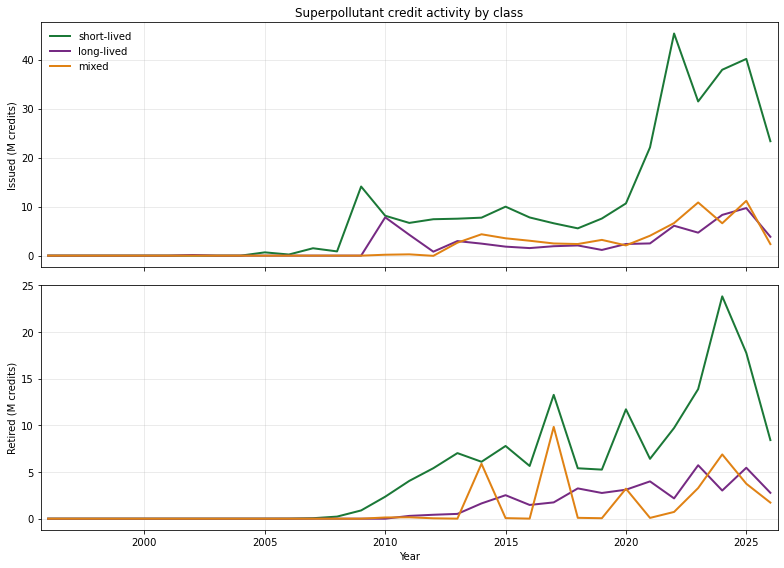

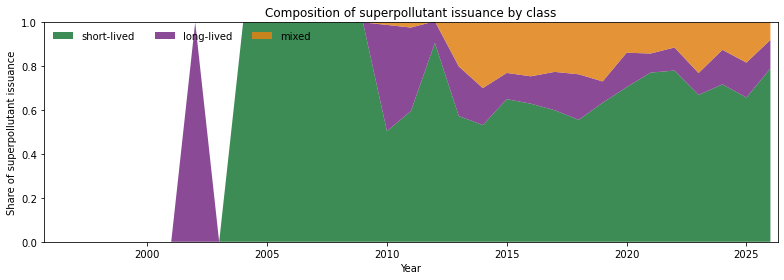

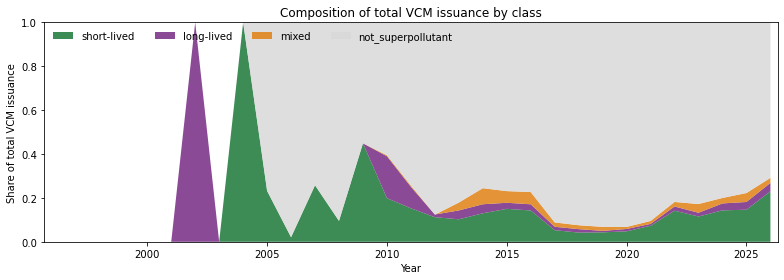

In [17]:
years = list(range(1996, 2027))
issuance_cols = [f'issuance_{y}' for y in years]
retired_cols  = [f'retired_{y}'  for y in years]

CLASS_ORDER = ['short-lived', 'long-lived', 'mixed', 'not_superpollutant']
SP_CLASSES  = CLASS_ORDER[:3]

# Sum each year column within each class -> year x class matrices
def class_ts(cols):
    return (
        vcm_df.groupby('slcp_project_class')[cols].sum()
        .rename(columns=lambda c: int(c.split('_')[1]))
        .reindex(CLASS_ORDER)
        .fillna(0)
        .T
    )

issued_ts_all  = class_ts(issuance_cols)
retired_ts_all = class_ts(retired_cols)
issued_ts, retired_ts = issued_ts_all[SP_CLASSES], retired_ts_all[SP_CLASSES]

colors = {'short-lived': '#1b7837', 'long-lived': '#762a83',
          'mixed': '#e08214', 'not_superpollutant': '#d9d9d9'}

# credit activity by class
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, ts, label in zip(axes, [issued_ts, retired_ts], ['Issued', 'Retired']):
    for cls in ts.columns:
        ax.plot(ts.index.to_numpy(), (ts[cls] / 1e6).to_numpy(),
                label=cls, color=colors[cls], lw=2)
    ax.set_ylabel(f'{label} (M credits)')
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)
axes[0].set_title('Superpollutant credit activity by class')
axes[0].legend(frameon=False)
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

# superpollutant credit share by class
share = issued_ts.div(issued_ts.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(share.index.to_numpy(), share.to_numpy().T,
             labels=list(share.columns),
             colors=[colors[c] for c in share.columns], alpha=0.85)
ax.set_ylim(0, 1)
ax.margins(x=0.01)
ax.set_ylabel('Share of superpollutant issuance')
ax.set_xlabel('Year')
ax.set_title('Composition of superpollutant issuance by class')
ax.legend(loc='upper left', frameon=False, ncol=3)
plt.tight_layout()
plt.show()

# total market credit share by class
market_share = issued_ts_all.div(issued_ts_all.sum(axis=1), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(market_share.index.to_numpy(), market_share.to_numpy().T,
             labels=list(market_share.columns),
             colors=[colors[c] for c in market_share.columns], alpha=0.85)
ax.set_ylim(0, 1)
ax.margins(x=0.01)
ax.set_ylabel('Share of total VCM issuance')
ax.set_xlabel('Year')
ax.set_title('Composition of total VCM issuance by class')
ax.legend(loc='upper left', frameon=False, ncol=4)
plt.tight_layout()
plt.show()

In [18]:
tbl = issued_ts.copy()
tbl['total'] = tbl.sum(axis=1)
tbl['cumulative_total'] = tbl['total'].cumsum()
tbl['cumulative_pct'] = 100 * (tbl['cumulative_total'] / tbl['total'].sum())
tbl.round(2)

slcp_project_class,short-lived,long-lived,mixed,total,cumulative_total,cumulative_pct
1996,0,0,0,0,0,0
1997,0,0,0,0,0,0
1998,0,0,0,0,0,0
1999,0,0,0,0,0,0
2000,0,0,0,0,0,0
2001,0,0,0,0,0,0
2002,0,"125,000",0,"125,000","125,000",0
2003,0,0,0,0,"125,000",0
2004,500,0,0,500,"125,500",0
2005,"668,510",0,0,"668,510","794,010",0


## Unpacking short-lived trends by protocol

Let's dig into the short-lived credit class. Given the short atmmospheric lifetime of the associated gas fluxes, this credit class is the most interesting from the perspective of temporal mismatches in offsetting, and how they might affect temperature outcomes. 

Questions we're interested in: 
- Do certain protocols or projects dominate credit issuance — cumulatively, or during recent years?
- Do certain protocols or projects dominate credit retirement — cumulatively, or during recent years?
- What's the composition of the SLCP credit backstock (protocols / projects)? What vintage years do those credits represent? Are people buying from those protocols and projects? 

Takeaways: 
Over all time, landfills have played the biggest role in SLCP issuance (CAR US Landfill Protocol + AMC001). Recently, though, we've seen two big growth protocols in recent years — [AM0023 Leak detection and repair in gas production, processing, transmission, storage and distribution systems and in refinery facilities](https://cdm.unfccc.int/methodologies/DB/PZN9ZCTGF3KHFH0W21NY0NYL6X5CIR), a CDM protocol being credited by Verra, and [ACR Transition to Advanced Formulation Blowing Agents in Foam Manufacturing and Use](https://acrcarbon.org/wp-content/uploads/2023/03/ACR-FBA-v3.0.pdf). Both of these are rapidly catching up with the CAR U.S. Landfill Protocol as the leading contributors to cumulative credit issuance. OOG also starting to grow?

In [19]:
SL = vcm_df[vcm_df['slcp_project_class'] == 'short-lived']

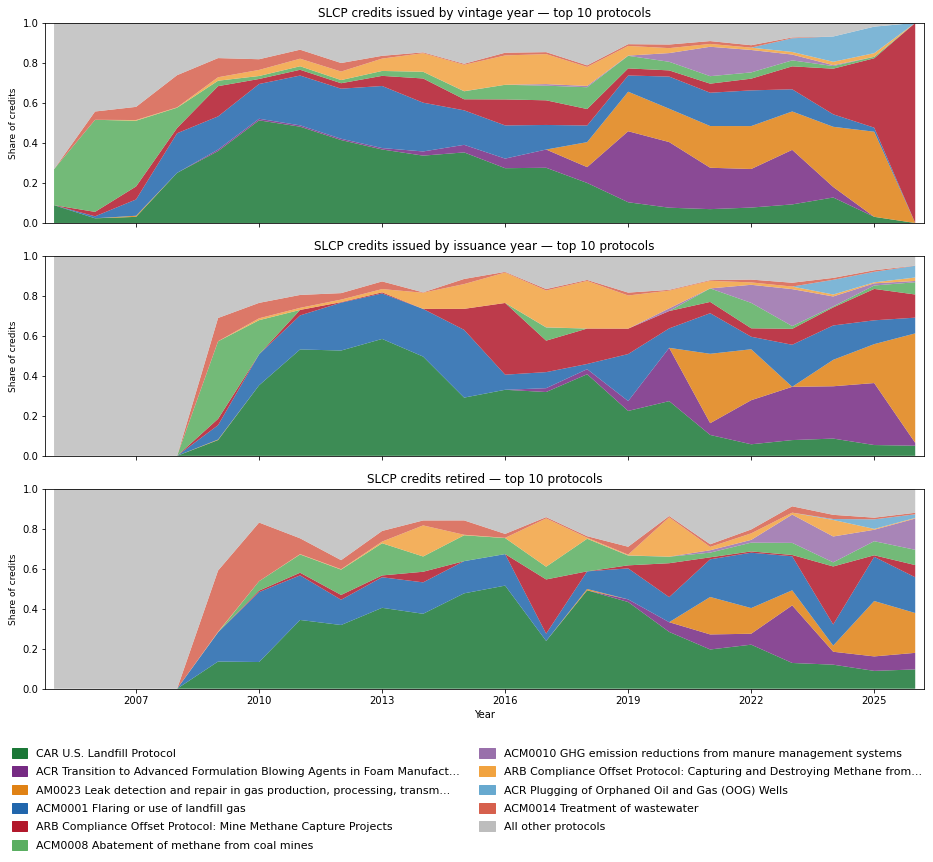

In [22]:
# ---- knobs ----
YEAR_START = 2005
YEAR_END = 2026
TOP_N = 10
SHARED_PROTOCOLS = True      # same protocols + same stacking order in every panel
RANK_BY = 'issuance'         # which panel picks the top N when SHARED_PROTOCOLS
PANELS = [('vintage',  'credits issued by vintage year'),
          ('issuance', 'credits issued by issuance year'),
          ('retired',  'credits retired')]
LEGEND_NCOL, LEGEND_FONTSIZE, LABEL_CHARS = 2, 11, 70
# --------------

OTHER = 'All other protocols'

def _ts(prefix):
    cols = [f'{prefix}_{y}' for y in range(YEAR_START, YEAR_END + 1)]
    return (SL.groupby('protocol')[cols].sum()
              .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

ts_by_panel  = {p: _ts(p) for p, _ in PANELS}
if SHARED_PROTOCOLS:
    named = ts_by_panel[RANK_BY].sum().nlargest(TOP_N).index.tolist()
    top_by_panel = {p: named for p, _ in PANELS}
else:
    top_by_panel = {p: ts_by_panel[p].sum().nlargest(TOP_N).index.tolist()
                    for p, _ in PANELS}
    named = []
    for p, _ in PANELS:
        for x in top_by_panel[p]:
            if x not in named:
                named.append(x)
    # re-sort each panel's columns into the shared `named` order
    top_by_panel = {p: [x for x in named if x in top_by_panel[p]] for p, _ in PANELS}
    
named = []                                   # union across all three, order preserved
for p, _ in PANELS:
    for x in top_by_panel[p]:
        if x not in named:
            named.append(x)

_BASE = ['#1b7837', '#762a83', '#e08214', '#2166ac', '#b2182b', '#5aae61',
         '#9970ab', '#f1a340', '#67a9cf', '#d6604d']
_EXTRA = [matplotlib.colors.to_hex(plt.get_cmap('tab20')(i)) for i in range(20)]
_POOL = _BASE + [c for c in _EXTRA if c not in _BASE]
COLORS = {p: _POOL[i % len(_POOL)] for i, p in enumerate(named)}
COLORS[OTHER] = '#bdbdbd'

def _stack(ts, top):
    top = [c for c in top if c in ts.columns]
    df = ts[top].copy()
    rest = ts.drop(columns=top)
    df[OTHER] = rest.sum(axis=1) if len(rest.columns) else 0.0
    return df.div(df.sum(axis=1), axis=0)

def short(s, n=LABEL_CHARS):
    return s if len(s) <= n else s[:n].rstrip() + '…'

legend_rows = int(np.ceil((len(named) + 1) / LEGEND_NCOL))
fig, axes = plt.subplots(len(PANELS), 1,
                         figsize=(13, 3.4 * len(PANELS)),
                         sharex=True)

for ax, (prefix, lab) in zip(axes, PANELS):
    sh = _stack(ts_by_panel[prefix], top_by_panel[prefix])
    ax.stackplot(sh.index.to_numpy(), np.nan_to_num(sh.to_numpy().T),
                 colors=[COLORS[c] for c in sh.columns], alpha=0.85)
    ax.set_ylim(0, 1)
    ax.margins(x=0.01)
    ax.set_ylabel('Share of credits', fontsize=9)
    ax.set_title(f'SLCP {lab} — top {TOP_N} protocols')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in named + [OTHER]]
fig.legend(handles, [short(p) for p in named + [OTHER]],
           loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=LEGEND_NCOL,
           frameon=False, fontsize=LEGEND_FONTSIZE, handlelength=1.4,
           handleheight=1.0, labelspacing=0.7, columnspacing=1.8)
axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

for prefix, _ in PANELS:
    others = [q for q, _ in PANELS if q != prefix]
    only = [p for p in top_by_panel[prefix]
            if not any(p in top_by_panel[o] for o in others)]

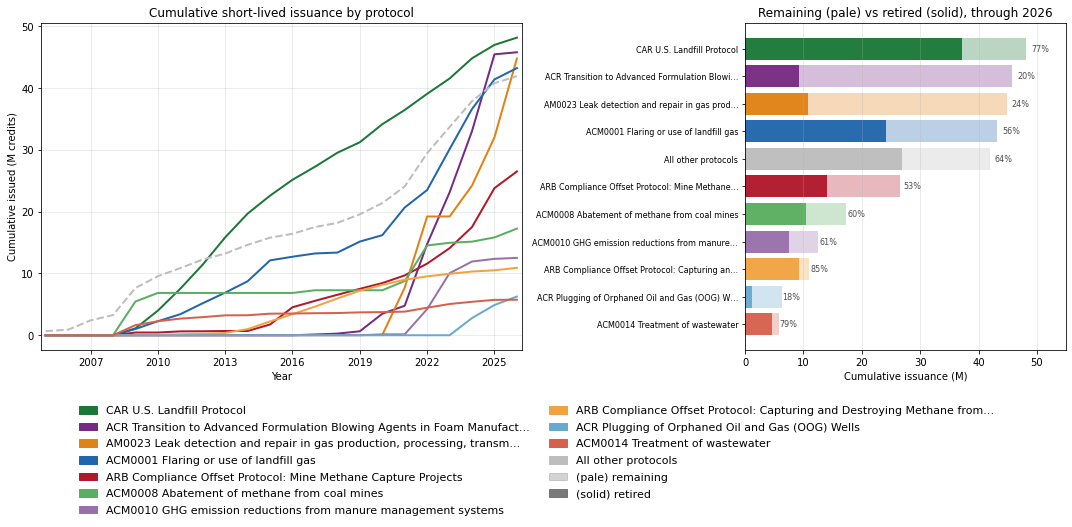

In [148]:
def _mat(prefix):
    cols = [f'{prefix}_{y}' for y in range(YEAR_START, YEAR_END + 1)]
    return (SL.groupby('protocol')[cols].sum()
              .rename(columns=lambda c: int(c.split('_')[1])).T)

iss, ret = _mat('issuance'), _mat('retired')
cum_named = iss.sum().nlargest(TOP_N_CUM).index.tolist()
COLORS = {p: _POOL[i % len(_POOL)] for i, p in enumerate(cum_named)}
COLORS[OTHER] = '#bdbdbd'

def _with_other(m):
    d = m[cum_named].copy()
    d[OTHER] = m.drop(columns=[c for c in cum_named if c in m.columns]).sum(axis=1)
    return d

cum_i, cum_r = _with_other(iss.cumsum()), _with_other(ret.cumsum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1.5, 1]})

ax = axes[0]
for c in cum_i.columns:
    ax.plot(cum_i.index.to_numpy(), (cum_i[c] / 1e6).to_numpy(),
            color=COLORS[c], lw=2, ls='--' if c == OTHER else '-')
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative issued (M credits)')
ax.set_title('Cumulative short-lived issuance by protocol')
ax.grid(alpha=0.3)
ax.margins(x=0.01)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = axes[1]
issued  = cum_i.iloc[-1] / 1e6
retired = (cum_r.iloc[-1] / 1e6).reindex(issued.index).fillna(0)
order = issued.sort_values().index
issued, retired = issued[order], retired[order]
ypos = np.arange(len(order))

ax2.barh(ypos, issued.to_numpy(),  color=[COLORS[c] for c in order], alpha=0.30)
ax2.barh(ypos, retired.to_numpy(), color=[COLORS[c] for c in order], alpha=0.95)
ax2.set_yticks(ypos)
ax2.set_yticklabels([short(i, 44) for i in order], fontsize=8)
for i, (iv, rv) in enumerate(zip(issued.to_numpy(), retired.to_numpy())):
    ax2.text(iv * 1.02, i, f'{100 * rv / iv:.0f}%' if iv else '—',
             va='center', fontsize=8, color='0.3')
ax2.set_xlabel('Cumulative issuance (M)')
ax2.set_title(f'Remaining (pale) vs retired (solid), through {YEAR_END}')
ax2.grid(axis='x', alpha=0.3)
ax2.margins(x=0.14)

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in cum_named + [OTHER]]
handles += [plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.30),
            plt.Rectangle((0, 0), 1, 1, color='0.45', alpha=0.95)]
labels = [short(p) for p in cum_named + [OTHER]] + ['(pale) remaining', '(solid) retired']
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.01),
           ncol=LEGEND_NCOL, frameon=False, fontsize=LEGEND_FONTSIZE,
           handlelength=1.6, labelspacing=0.6, columnspacing=1.8)
plt.tight_layout()
plt.show()

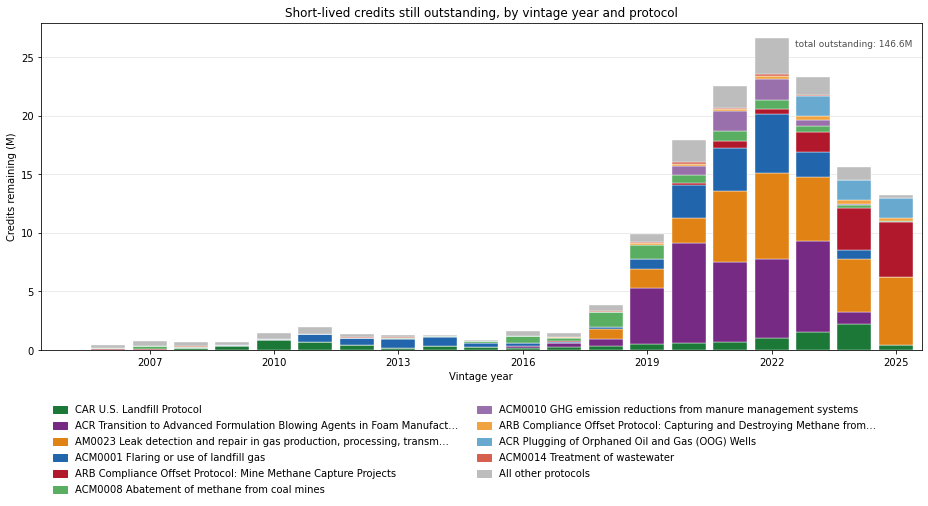

weighted mean vintage age: 4.0 years


,remaining_M,age_yrs,pct
2005,0,20,0
2006,0,19,0
2007,1,18,1
2008,1,17,0
2009,1,16,0
2010,1,15,1
2011,2,14,1
2012,1,13,1
2013,1,12,1
2014,1,11,1


In [23]:
# reuses `named` and `COLORS` from the previous chart
YEAR_START, YEAR_END = 2005, 2025
LEGEND_NCOL, LEGEND_FONTSIZE, LABEL_CHARS = 2, 10, 70
OTHER = 'All other protocols'

def short(s, n=LABEL_CHARS):
    return s if len(s) <= n else s[:n].rstrip() + '…'

cols = [f'remaining_vintage_{y}' for y in range(YEAR_START, YEAR_END + 1)]
rem = (SL.groupby('protocol')[cols].sum()
         .rename(columns=lambda c: int(c.rsplit('_', 1)[1])).T)

stack_order = [p for p in named if p in rem.columns]
df = rem[stack_order].copy()
rest = rem.drop(columns=stack_order)
df[OTHER] = rest.sum(axis=1) if len(rest.columns) else 0.0
df = df / 1e6

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(len(df))
for c in df.columns:
    ax.bar(df.index.to_numpy(), df[c].to_numpy(), bottom=bottom,
           color=COLORS[c], width=0.82, edgecolor='white', linewidth=0.4)
    bottom += df[c].to_numpy()

ax.set_xlabel('Vintage year')
ax.set_ylabel('Credits remaining (M)')
ax.set_title('Short-lived credits still outstanding, by vintage year and protocol')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.margins(x=0.01)
ax.text(0.99, 0.95, f'total outstanding: {df.sum().sum():,.1f}M',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='0.3')

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[p]) for p in stack_order + [OTHER]]
fig.legend(handles, [short(p) for p in stack_order + [OTHER]],
           loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=LEGEND_NCOL,
           frameon=False, fontsize=LEGEND_FONTSIZE, handlelength=1.4,
           labelspacing=0.6, columnspacing=1.8)
plt.tight_layout()
plt.show()

# vintage-age profile of the outstanding stock
age = pd.DataFrame({'remaining_M': df.sum(axis=1)})
age['age_yrs'] = YEAR_END - age.index
age['pct'] = 100 * age['remaining_M'] / age['remaining_M'].sum()
print(f"weighted mean vintage age: "
      f"{np.average(age['age_yrs'], weights=age['remaining_M']):.1f} years")
age.round(2)

## Unpacking SLCP credits by project / developer

In [26]:
# project-level issuance concentration


RECENT = [f'issuance_{y}' for y in range(2021, 2027)]  
ALL_YRS = [f'issuance_{y}' for y in range(1996, 2027)]

proj = pd.DataFrame({
    'issued_all':    SL[ALL_YRS].sum(axis=1),
    'issued_recent': SL[RECENT].sum(axis=1),
})
proj = proj.join(SL[['project_id', 'project_name', 'developer', 'region',
                     'protocol', 'n_protocols', 'registry', 'scope', 'project_vintage_yr', 'registry']])

tot_all, tot_recent = proj['issued_all'].sum(), proj['issued_recent'].sum()
proj['pct_all']    = 100 * proj['issued_all']    / tot_all
proj['pct_recent'] = 100 * proj['issued_recent'] / tot_recent

DISP = ['project_id', 'project_name', 'developer', 'region',
        'protocol', 'issued_all', 'pct_all', 'issued_recent', 'pct_recent', 'project_vintage_yr','registry']

print(f'{len(proj):,} short-lived projects | {tot_all/1e6:,.1f}M issued all-time, '
      f'{tot_recent/1e6:,.1f}M in 2021-25\n')

print('=== TOP 15 CUMULATIVE ===')
display(proj.nlargest(15, 'issued_all')[DISP].round(2))

print('=== TOP 15 RECENT (2021-25) ===')
display(proj.nlargest(15, 'issued_recent')[DISP].round(2))

1,880 short-lived projects | 303.2M issued all-time, 200.2M in 2021-25

=== TOP 15 CUMULATIVE ===


,project_id,project_name,developer,region,protocol,issued_all,pct_all,issued_recent,pct_recent,project_vintage_yr,registry,registry
9010,VCS2930,Reducing Gas Leakages within the Titas Gas Dis...,NE Climate A/S,Southern Asia,AM0023 Leak detection and repair in gas produc...,"12,385,324",4,"12,385,324",6,"2,021",VCS,VCS
10359,VCS4531,Reducing Gas Leakages within the Hududgaz Gas ...,GasGreen Asia LLC,Central Asia,AM0023 Leak detection and repair in gas produc...,"11,789,486",4,"11,789,486",6,"2,023",VCS,VCS
8624,VCS2478,Reducing Gas Leakages within the Titas Gas Dis...,Converted from other GHG program,Southern Asia,AM0023 Leak detection and repair in gas produc...,"7,657,147",3,"7,657,147",4,"2,018",VCS,VCS
8835,VCS2736,Reducing Gas Leakages within the Bakhrabad Gas...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"4,274,290",1,"4,274,290",2,"2,019",VCS,VCS
8836,VCS2737,Reducing Gas Leakages within the Jalalabad Gas...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"3,305,700",1,"3,305,700",2,"2,019",VCS,VCS
2326,GS440,*Mamak Landfill Waste Management Project Turkey,ITC Invest Trading & Consulting AG Ankara Branch,Western Asia,ACM0001 Flaring or use of landfill gas,"3,192,403",1,0,0,"2,007",GOLD,GOLD
7896,VCS1446,Sichuan Furong Coal Mine Methane Utilization P...,Sichuan Furong Group's Limited Industrial Company,Eastern Asia,ACM0008 Abatement of methane from coal mines,"2,792,506",1,"2,358,127",1,"2,010",VCS,VCS
8837,VCS2738,Reducing Gas Leakages within the Karnaphuli Ga...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"2,747,860",1,"2,747,860",1,"2,019",VCS,VCS
1365,CAR1105,American Soda LLC Waste Mine Methane Project,American Soda LLC,North America,ARB Compliance Offset Protocol: Mine Methane C...,"2,642,380",1,"1,421,144",1,"2,015",CAR,CAR
3214,GS3434,GS3434 Uberlândia landfills I and II,Energas Geracao de Energia Ltda,Latin America and the Caribbean,ACM0001 Flaring or use of landfill gas,"2,479,979",1,"2,135,937",1,"2,013",GOLD,GOLD


=== TOP 15 RECENT (2021-25) ===


,project_id,project_name,developer,region,protocol,issued_all,pct_all,issued_recent,pct_recent,project_vintage_yr,registry,registry
9010,VCS2930,Reducing Gas Leakages within the Titas Gas Dis...,NE Climate A/S,Southern Asia,AM0023 Leak detection and repair in gas produc...,"12,385,324",4,"12,385,324",6,"2,021",VCS,VCS
10359,VCS4531,Reducing Gas Leakages within the Hududgaz Gas ...,GasGreen Asia LLC,Central Asia,AM0023 Leak detection and repair in gas produc...,"11,789,486",4,"11,789,486",6,"2,023",VCS,VCS
8624,VCS2478,Reducing Gas Leakages within the Titas Gas Dis...,Converted from other GHG program,Southern Asia,AM0023 Leak detection and repair in gas produc...,"7,657,147",3,"7,657,147",4,"2,018",VCS,VCS
8835,VCS2736,Reducing Gas Leakages within the Bakhrabad Gas...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"4,274,290",1,"4,274,290",2,"2,019",VCS,VCS
8836,VCS2737,Reducing Gas Leakages within the Jalalabad Gas...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"3,305,700",1,"3,305,700",2,"2,019",VCS,VCS
8837,VCS2738,Reducing Gas Leakages within the Karnaphuli Ga...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"2,747,860",1,"2,747,860",1,"2,019",VCS,VCS
8727,VCS2605,İZMIR LANDFILL GAS (LFG) CAPTURE AND UTILIZATI...,Multiple Proponents,Western Asia,ACM0001 Flaring or use of landfill gas,"2,445,711",1,"2,445,711",1,"2,019",VCS,VCS
7896,VCS1446,Sichuan Furong Coal Mine Methane Utilization P...,Sichuan Furong Group's Limited Industrial Company,Eastern Asia,ACM0008 Abatement of methane from coal mines,"2,792,506",1,"2,358,127",1,"2,010",VCS,VCS
471,ACR0656,Whirlpool HFO Amana 656,WHIRLPOOL CORPORATION,North America,ACR Transition to Advanced Formulation Blowing...,"2,149,053",1,"2,149,053",1,"2,019",ACR,ACR
3214,GS3434,GS3434 Uberlândia landfills I and II,Energas Geracao de Energia Ltda,Latin America and the Caribbean,ACM0001 Flaring or use of landfill gas,"2,479,979",1,"2,135,937",1,"2,013",GOLD,GOLD


In [25]:
# project-level retirement concentration
SL = vcm_df[vcm_df['slcp_project_class'] == 'short-lived']

RECENT  = [f'retired_{y}' for y in range(2021, 2026)]   # 2026 partial, excluded
ALL_YRS = [f'retired_{y}' for y in range(1996, 2026)]

proj = pd.DataFrame({
    'retired_all':    SL[ALL_YRS].sum(axis=1),
    'retired_recent': SL[RECENT].sum(axis=1),
})
proj = proj.join(SL[['project_id', 'project_name', 'developer', 'region',
                     'protocol', 'n_protocols', 'registry', 'scope', 'project_vintage_yr']])

tot_all, tot_recent = proj['retired_all'].sum(), proj['retired_recent'].sum()
proj['pct_all']    = 100 * proj['retired_all']    / tot_all
proj['pct_recent'] = 100 * proj['retired_recent'] / tot_recent

DISP = ['project_id', 'project_name', 'developer', 'region', 'protocol',
        'retired_all', 'pct_all', 'retired_recent', 'pct_recent', 'project_vintage_yr']

print(f'{len(proj):,} short-lived projects | {tot_all/1e6:,.1f}M retired all-time, '
      f'{tot_recent/1e6:,.1f}M in 2021-25\n')

print('=== TOP 15 CUMULATIVE ===')
display(proj.nlargest(15, 'retired_all')[DISP].round(2))

print('=== TOP 15 RECENT (2021-25) ===')
display(proj.nlargest(15, 'retired_recent')[DISP].round(2))

1,880 short-lived projects | 146.7M retired all-time, 71.6M in 2021-25

=== TOP 15 CUMULATIVE ===


,project_id,project_name,developer,region,protocol,retired_all,pct_all,retired_recent,pct_recent,project_vintage_yr
8624,VCS2478,Reducing Gas Leakages within the Titas Gas Dis...,Converted from other GHG program,Southern Asia,AM0023 Leak detection and repair in gas produc...,"5,463,931",4,"5,463,931",8,"2,018"
2326,GS440,*Mamak Landfill Waste Management Project Turkey,ITC Invest Trading & Consulting AG Ankara Branch,Western Asia,ACM0001 Flaring or use of landfill gas,"3,192,998",2,"672,807",1,"2,007"
21,ACR0126,Seneca Meadows LFG,Seneca Meadows,North America,Offset Project Methodology for Landfill Methan...,"1,770,485",1,"321,633",0,"2,010"
1160,CAR674,"Oneida Herkimer Landfill Ava, NY",Oneida Herkimer Solid Waste Authority,North America,CAR U.S. Landfill Protocol,"1,715,220",1,"669,261",1,"2,010"
1365,CAR1105,American Soda LLC Waste Mine Methane Project,American Soda LLC,North America,ARB Compliance Offset Protocol: Mine Methane C...,"1,667,997",1,"861,682",1,"2,015"
107,ACR0226,Marshall County VAM Abatement Project,"NextEra Energy Marketing, LLC",North America,ARB Compliance Offset Protocol: Mine Methane C...,"1,585,577",1,"545,259",1,"2,014"
2306,GS397,*Suzhou Qizi Mountain Landfill Gas Recovery Pr...,South Pole Ltd,Eastern Asia,ACM0001 Flaring or use of landfill gas,"1,483,412",1,"588,261",1,"2,007"
6478,VCS13,Coal Mine Methane Capture and Use Project at t...,"Peabody Natural Gas, LLC",North America,ARB Compliance Offset Protocol: Mine Methane C...,"1,407,634",1,"372,997",1,"2,006"
7896,VCS1446,Sichuan Furong Coal Mine Methane Utilization P...,Sichuan Furong Group's Limited Industrial Company,Eastern Asia,ACM0008 Abatement of methane from coal mines,"1,383,317",1,"1,207,311",2,"2,010"
10359,VCS4531,Reducing Gas Leakages within the Hududgaz Gas ...,GasGreen Asia LLC,Central Asia,AM0023 Leak detection and repair in gas produc...,"1,348,958",1,"1,348,958",2,"2,023"


=== TOP 15 RECENT (2021-25) ===


,project_id,project_name,developer,region,protocol,retired_all,pct_all,retired_recent,pct_recent,project_vintage_yr
8624,VCS2478,Reducing Gas Leakages within the Titas Gas Dis...,Converted from other GHG program,Southern Asia,AM0023 Leak detection and repair in gas produc...,"5,463,931",4,"5,463,931",8,"2,018"
10359,VCS4531,Reducing Gas Leakages within the Hududgaz Gas ...,GasGreen Asia LLC,Central Asia,AM0023 Leak detection and repair in gas produc...,"1,348,958",1,"1,348,958",2,"2,023"
7896,VCS1446,Sichuan Furong Coal Mine Methane Utilization P...,Sichuan Furong Group's Limited Industrial Company,Eastern Asia,ACM0008 Abatement of methane from coal mines,"1,383,317",1,"1,207,311",2,"2,010"
252,ACR0407,BMMC1,Environmental Commodities Corporation,North America,ARB Compliance Offset Protocol: Mine Methane C...,"1,026,292",1,"1,026,292",1,"2,018"
3214,GS3434,GS3434 Uberlândia landfills I and II,Energas Geracao de Energia Ltda,Latin America and the Caribbean,ACM0001 Flaring or use of landfill gas,"971,482",1,"971,482",1,"2,013"
7692,VCS1240,Joburg Landfill Gas to Energy Project,Energy Joburg RF (PTY) Limited,Sub-Saharan Africa,ACM0001 Flaring or use of landfill gas,"1,052,117",1,"968,876",1,"2,011"
4692,GS11334,Heilongjiang Swine Farm Animal Waste Managemen...,Profit Carbon Environmental Energy Technology ...,Eastern Asia,ACM0010 GHG emission reductions from manure ma...,"960,215",1,"960,215",1,"2,020"
4695,GS11337,Shuangbaotai Animal Manure Management System G...,Profit Carbon Environmental Energy Technology ...,Eastern Asia,ACM0010 GHG emission reductions from manure ma...,"945,192",1,"945,192",1,"2,020"
8837,VCS2738,Reducing Gas Leakages within the Karnaphuli Ga...,Multiple Proponents,Southern Asia,AM0023 Leak detection and repair in gas produc...,"923,967",1,"923,967",1,"2,019"
8555,VCS2402,Linshu Biogas Recovery and Power Generation Pr...,VPOWER New Energy Technology (LinYi) LTD,Eastern Asia,ACM0014 Treatment of wastewater,"900,700",1,"900,700",1,"2,019"


AM0021 is clearly playing a huge role. You can get a pretty good picture of things quickly since it only has 11 projects developed under it, and nine credited projects. Of those, seven are in Bangladesh. So, super concentrated geographically — I'd be curious if all of these projects are connected to the state. It's also notable that retirement across the projects is very lumpy. By far the project with the most absolute retirement and highest retirement rate is [VCS2478](https://carbonplan.org/research/offsets-db/projects/VCS2478). Biggest named retirements are by Delta on OffsetDB, but it also looks like it and VCM2930 are part of [BP's portfolio](https://www.bp.com/en_gb/carbon-connect/home/our-carbon-credit-portfolio/our-current-portfolio/titas-gas-methane-leak-reduction.html). 

In [51]:
AM0023 = ("AM0023 Leak detection and repair in gas production, processing, "
          "transmission, storage and distribution systems and in refinery facilities")

ALL_ISS, REC_ISS = [f'issuance_{y}' for y in range(1996, 2026)], [f'issuance_{y}' for y in range(2021, 2026)]
ALL_RET, REC_RET = [f'retired_{y}'  for y in range(1996, 2026)], [f'retired_{y}'  for y in range(2021, 2026)]

gas = proj[proj['protocol'] == AM0023].copy()
gas['issued_all']     = SL.loc[gas.index, ALL_ISS].sum(axis=1)
gas['issued_recent']  = SL.loc[gas.index, REC_ISS].sum(axis=1)
gas['retired_recent'] = SL.loc[gas.index, REC_RET].sum(axis=1)

DISP = ['project_id', 'project_name', 'developer', 'region', 'project_vintage_yr',
        'issued_all', 'issued_recent', 'retired_recent']

gas.sort_values('issued_all', ascending=False)[DISP].round(2)

,project_id,project_name,developer,region,project_vintage_yr,issued_all,issued_recent,retired_recent
9010,VCS2930,Reducing Gas Leakages within the Titas Gas Dis...,NE Climate A/S,Southern Asia,"2,021","8,273,584","8,273,584","395,124"
8624,VCS2478,Reducing Gas Leakages within the Titas Gas Dis...,Converted from other GHG program,Southern Asia,"2,018","7,657,147","7,657,147","5,463,931"
8835,VCS2736,Reducing Gas Leakages within the Bakhrabad Gas...,Multiple Proponents,Southern Asia,"2,019","4,274,290","4,274,290","190,952"
10359,VCS4531,Reducing Gas Leakages within the Hududgaz Gas ...,GasGreen Asia LLC,Central Asia,"2,023","3,849,288","3,849,288","1,348,958"
8836,VCS2737,Reducing Gas Leakages within the Jalalabad Gas...,Multiple Proponents,Southern Asia,"2,019","3,305,700","3,305,700","401,880"
8837,VCS2738,Reducing Gas Leakages within the Karnaphuli Ga...,Multiple Proponents,Southern Asia,"2,019","2,747,860","2,747,860","923,967"
9086,VCS3021,Reducing Gas Leakages within North West and ot...,Carbon Projects LLC,Southern Asia,"2,022","975,895","975,895","5,691"
8838,VCS2739,Reducing Gas Leakages within the Pashchimancha...,Multiple Proponents,Southern Asia,"2,020","917,523","917,523","407,177"
6576,VCS115,Reduction of methane emissions in the low pres...,Core Carbon Group ApS,Eastern Europe,"2,007","35,582",0,0
11086,VCS5479,"LEAK DETECTION AND REPAIR PROGRAM - GLI, AZERB...",ICA-Finance AS,Western Asia,NaN,0,0,0


ACR foam projects are a different story. They've been developed since 2009, but the bulk of projects came online 2016-2023. Mostly, these projects are in North America, and the bulk have been developed by Foam Supplies Inc. and Whirlpool Corporation. These credits are given for using a lower GWP blowing agent in the production of foam. Common baseline blowing agents per the protocol include HFC-152a, HFC-365mfc, HFC245fa, and HFC134a — which are pretty short lived (1.5-13.4 years). 

In [60]:
FOAM = "ACR Transition to Advanced Formulation Blowing Agents in Foam Manufacturing and Use"

ALL_ISS, REC_ISS = [f'issuance_{y}' for y in range(1996, 2026)], [f'issuance_{y}' for y in range(2021, 2026)]
ALL_RET, REC_RET = [f'retired_{y}'  for y in range(1996, 2026)], [f'retired_{y}'  for y in range(2021, 2026)]

foam = proj[proj['protocol'] == FOAM].copy()
foam['issued_all']     = SL.loc[foam.index, ALL_ISS].sum(axis=1)
foam['issued_recent']  = SL.loc[foam.index, REC_ISS].sum(axis=1)
foam['retired_recent'] = SL.loc[foam.index, REC_RET].sum(axis=1)

DISP = ['project_id', 'project_name', 'developer', 'region', 'project_vintage_yr',
        'issued_all', 'issued_recent', 'retired_recent']

foam.sort_values('issued_all', ascending=False)[DISP].head(30).round(2)

,project_id,project_name,developer,region,project_vintage_yr,issued_all,issued_recent,retired_recent
471,ACR0656,Whirlpool HFO Amana 656,WHIRLPOOL CORPORATION,North America,"2,019","2,149,053","2,149,053","476,273"
477,ACR0662,Whirlpool HFO Supsa 662,WHIRLPOOL CORPORATION,Latin America and the Caribbean,"2,020","2,074,459","2,074,459","5,087"
736,ACR0975,Foam Blowing Agent Project 004-2023,"Foam Supplies, Inc. 2",North America,"2,023","2,047,598","2,047,598","6,233"
440,ACR0622,Foam Blowing Agent Project 003F,"Foam Supplies, Inc. 2",North America,"2,020","1,934,327","1,934,327","803,454"
580,ACR0797,Whirlpool HFO Supsa 797,WHIRLPOOL CORPORATION,Latin America and the Caribbean,"2,021","1,712,931","1,712,931",0
472,ACR0657,Whirlpool HFO Amana 657,WHIRLPOOL CORPORATION,North America,"2,020","1,698,251","1,698,251",0
381,ACR0556,Foam Blowing Agent Project 005,"Foam Supplies, Inc. 2",North America,"2,019","1,666,749","1,137,557","254,151"
439,ACR0621,Spray Foam Omega 3,"Brian R. Anderson, Inc. DBA 1st Climate Solutions",North America,"2,020","1,610,884","1,610,884","190,248"
753,ACR0997,Whirlpool HFO Supsa 997,WHIRLPOOL CORPORATION,Latin America and the Caribbean,"2,022","1,603,000","1,603,000",0
757,ACR1001,Whirlpool HFO Supsa 1001,WHIRLPOOL CORPORATION,Latin America and the Caribbean,"2,023","1,568,319","1,568,319",0


In [55]:
foam['project_vintage_yr'].value_counts().sort_index()

project_vintage_yr
2,009     1
2,010     1
2,011     1
2,012     1
2,013     1
2,014     3
2,015     4
2,016     6
2,017     6
2,018     6
2,019     9
2,020    10
2,021    11
2,022    11
2,023     9
2,024     2
Name: count, dtype: int64

In [65]:
foam[['developer','region']].value_counts().sort_index()

developer                                          region                         
Brian R. Anderson, Inc. DBA 1st Climate Solutions  North America                      12
Foam Supplies, Inc. 2                              North America                      31
Honeywell International                            North America                       8
True Manufacturing Co., Inc.                       North America                       7
WHIRLPOOL CORPORATION                              Latin America and the Caribbean     9
                                                   North America                      15
Name: count, dtype: int64

In [117]:
LANDFILL = "CAR U.S. Landfill Protocol"

landfill = proj[proj['protocol'] == LANDFILL].copy()
landfill['issued_all']     = SL.loc[landfill.index, ALL_ISS].sum(axis=1)
landfill['issued_recent']  = SL.loc[landfill.index, REC_ISS].sum(axis=1)
landfill['retired_recent'] = SL.loc[landfill.index, REC_RET].sum(axis=1)

DISP = ['project_id', 'project_name', 'developer', 'region', 'project_vintage_yr',
        'issued_all', 'issued_recent', 'retired_recent']

landfill.sort_values('issued_all', ascending=False)[DISP].head(30).round(2)

,project_id,project_name,developer,region,project_vintage_yr,issued_all,issued_recent,retired_recent
1021,CAR400,South Jordan Landfill Gas Destruction Project,"Anew Environmental, LLC",North America,"2,009","2,053,918","883,275","538,615"
1160,CAR674,"Oneida Herkimer Landfill Ava, NY",Oneida Herkimer Solid Waste Authority,North America,"2,010","1,962,369","916,410","669,261"
1141,CAR621,Kimble Sanitary Landfill Gas Project,Kimble Company,North America,"2,010","1,684,325","522,418","301,536"
1070,CAR475,Gaston County Landfill Gas Destruction Project,Gaston County Solid Waste and Recycling,North America,"2,008","1,510,700","530,196","362,723"
1147,CAR635,Hancock County Landfill Gas Collection Project,"3Degrees Group, Inc",North America,"2,010","1,467,718","447,606","425,251"
1071,CAR476,Eagle Point Landfill,Sustainable Energy Solutions LLC,North America,"2,009","1,420,671",0,"385,129"
1046,CAR443,South Kent Landfill Gas to Energy Project,"3Degrees Group, Inc",North America,"2,008","1,330,661","516,951","555,494"
1089,CAR498,Wolf Creek Landfill,Sustainable Energy Solutions LLC,North America,"2,010","1,165,003",0,"342,695"
1068,CAR473,Davis Landfill Gas Offset Project,"Anew Environmental, LLC",North America,"2,008","1,059,899","613,984","391,407"
1040,CAR435,Northeast Mississippi Landfill,"Waste Services of N. E. Mississippi, Inc.",North America,"2,008","1,018,502",0,0
